In [1]:
import joblib
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import brier_score_loss
from sklearn.metrics import log_loss


from sklearn.calibration import calibration_curve


from src.load_tests import get_model_type
from src.load_tests import load_test

## Nacitanie modelov

In [ ]:
model_lists: list[str] = ["lr4U_c10", "lr4Ui_c10", "lr4Us_c10"]
base_path: str = "../results"
tests = {}

for model in model_lists:
    model_type = get_model_type(model)
    path = os.path.join(base_path, model_type, model)
    print(path)

    tests[model] = load_test(path)
    

../results/lr/lr4_c10
../results/lr/lr4U_c10


## Brier Score

In [3]:
for test, data in tests.items():
    score: float = brier_score_loss(data["y_true"], data["y_proba"]) # type: ignore
    print(test, round(score, 5))

lr4_c10 0.1398
lr4U_c10 0.13747


## Log loss

In [4]:
for test, data in tests.items():
    score: float = log_loss(data["y_true"], data["y_proba"]) # type: ignore
    print(test, round(score, 5))

lr4_c10 0.4381
lr4U_c10 0.43487


## Expected Calibration Error (ECE)

In [5]:
def get_ece(y_true, y_proba, n_bins: int):
    bins: list[float] = np.linspace(0, 1, n_bins+1) # type: ignore
    ece: float = 0.0

    for i in range(n_bins):
        mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
    
        if np.sum(mask) > 0:
            accuracy: float = np.mean(y_true[mask])
            confidency:float  = np.mean(y_proba[mask])
            ece += np.abs(accuracy - confidency) * np.sum(mask) / len(y_true)
    
    return ece


for test, data in tests.items():
    ece: float = get_ece(data["y_true"], data["y_proba"], 10)
    print(test, round(ece, 5))

lr4_c10 0.12024
lr4U_c10 0.10677


## Reliability Diagam

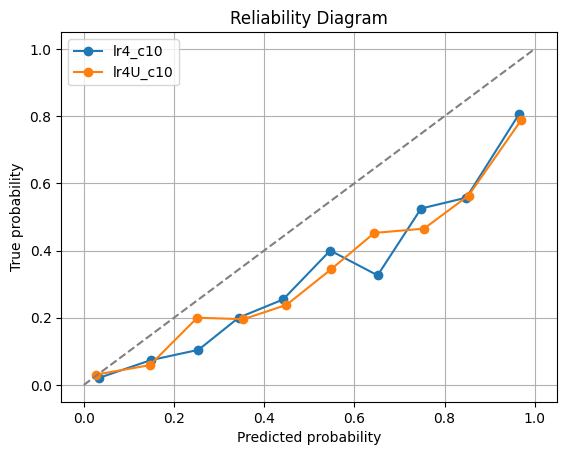

In [6]:
for test, data in tests.items():
    y_true = data["y_true"]
    y_proba = data["y_proba"]
    
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=test)

# ideálna čiara
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Reliability Diagram")
plt.legend()
plt.grid()
plt.show()

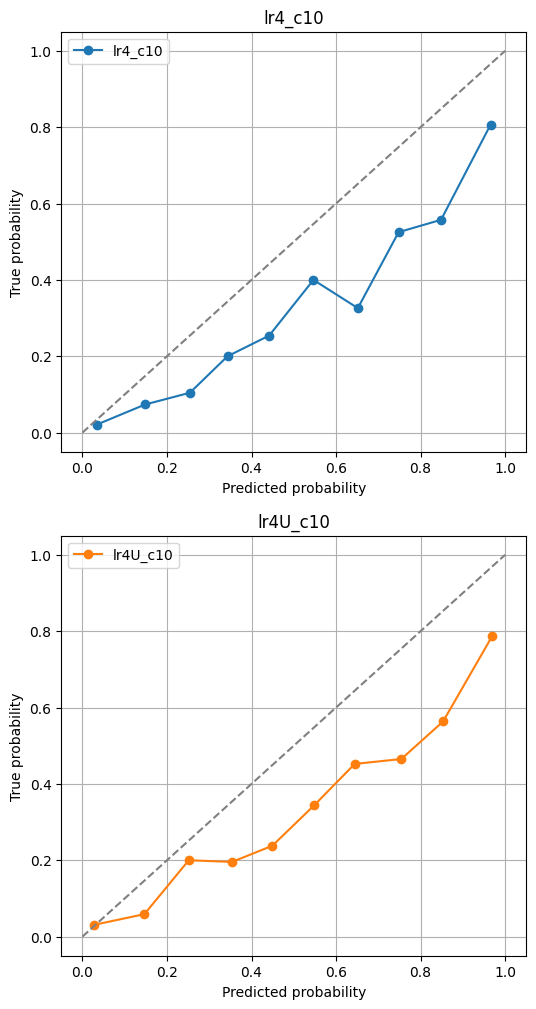

In [7]:
N: int = len(tests)
fig, axes = plt.subplots(nrows=N,
                         ncols=1,
                         figsize=(6, 6*N))

col_pallet: list[str] = [
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#d62728',
    '#9467bd',
    '#8c564b'
    ]

if N == 1:
    axes = [axes]

prob_ture_list: list = []
prob_pred_list: list = []

for test, data in tests.items():
    y_true = data["y_true"]
    y_proba = data["y_proba"]

    prob_ture, prob_pred = calibration_curve(
        y_true,
        y_proba,
        n_bins=10
    )

    prob_ture_list.append(prob_ture)
    prob_pred_list.append(prob_pred)


for i, (test, data) in enumerate(tests.items()):
    axes[i].plot(prob_pred_list[i], prob_ture_list[i], marker="o", label=test, color=col_pallet[i])
    axes[i].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[i].set_xlabel("Predicted probability")
    axes[i].set_ylabel("True probability")
    axes[i].set_title(test)
    axes[i].legend()
    axes[i].grid()